In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv(r"D:\personal\Project\credit_test.csv")
print(df.shape)
df.head()

(10353, 18)


,Loan ID,Customer ID,Current Loan Amount,Term,Credit Score,Annual Income,Years in current job,Home Ownership,Purpose,Monthly Debt,Years of Credit History,Months since last delinquent,Number of Open Accounts,Number of Credit Problems,Current Credit Balance,Maximum Open Credit,Bankruptcies,Tax Liens
0,f738779f-c726-40dc-92cf-689d73af533d,ded0b3c3-6bf4-4091-8726-47039f2c1b90,611314.0,Short Term,747.0,2074116.0,10+ years,Home Mortgage,Debt Consolidation,42000.83,21.8,NaN,9.0,0.0,621908.0,1058970.0,0.0,0.0
1,6dcc0947-164d-476c-a1de-3ae7283dde0a,1630e6e3-34e3-461a-8fda-09297d3140c8,266662.0,Short Term,734.0,1919190.0,10+ years,Home Mortgage,Debt Consolidation,36624.40,19.4,NaN,11.0,0.0,679573.0,904442.0,0.0,0.0
2,f7744d01-894b-49c3-8777-fc6431a2cff1,2c60938b-ad2b-4702-804d-eeca43949c52,153494.0,Short Term,709.0,871112.0,2 years,Rent,Debt Consolidation,8391.73,12.5,10.0,10.0,0.0,38532.0,388036.0,0.0,0.0
3,83721ffb-b99a-4a0f-aea5-ef472a138b41,12116614-2f3c-4d16-ad34-d92883718806,176242.0,Short Term,727.0,780083.0,10+ years,Rent,Debt Consolidation,16771.87,16.5,27.0,16.0,1.0,156940.0,531322.0,1.0,0.0
4,08f3789f-5714-4b10-929d-e1527ab5e5a3,39888105-fd5f-4023-860a-30a3e6f5ccb7,321992.0,Short Term,744.0,1761148.0,10+ years,Home Mortgage,Debt Consolidation,39478.77,26.0,44.0,14.0,0.0,359765.0,468072.0,0.0,0.0


In [37]:
print(df.dtypes)
print("\n")
print(df.isnull().sum())

Loan ID                          object
Customer ID                      object
Current Loan Amount             float64
Term                             object
Credit Score                    float64
Annual Income                   float64
Years in current job             object
Home Ownership                   object
Purpose                          object
Monthly Debt                    float64
Years of Credit History         float64
Months since last delinquent    float64
Number of Open Accounts         float64
Number of Credit Problems       float64
Current Credit Balance          float64
Maximum Open Credit             float64
Bankruptcies                    float64
Tax Liens                       float64
dtype: object


Loan ID                          353
Customer ID                      353
Current Loan Amount              353
Term                             353
Credit Score                    2334
Annual Income                   2334
Years in current job             780
Home 

In [38]:
df.dropna(how='all', inplace=True)
print("After dropping empty rows:", df.shape)

After dropping empty rows: (10000, 18)


In [39]:
print(df['Term'].value_counts())

Term
Short Term    7295
Long Term     2705
Name: count, dtype: int64


In [40]:
print(df['Years in current job'].value_counts())

Years in current job
10+ years    3085
2 years       916
3 years       866
< 1 year      795
5 years       696
1 year        648
4 years       613
6 years       566
7 years       554
8 years       472
9 years       362
Name: count, dtype: int64


In [41]:
# Convert text to numbers
df['Years in current job'] = df['Years in current job'].str.extract('(\d+)').astype(float)

# Fill missing values with median
df['Years in current job'].fillna(df['Years in current job'].median(), inplace=True)

print(df['Years in current job'].value_counts())
print("Nulls remaining:", df['Years in current job'].isnull().sum())

Years in current job
10.0    3085
1.0     1443
6.0      993
2.0      916
3.0      866
5.0      696
4.0      613
7.0      554
8.0      472
9.0      362
Name: count, dtype: int64
Nulls remaining: 0


In [42]:
# Fill Credit Score nulls with median
df['Credit Score'].fillna(df['Credit Score'].median(), inplace=True)

# Fill Annual Income nulls with median
df['Annual Income'].fillna(df['Annual Income'].median(), inplace=True)

# Fill Bankruptcies and Tax Liens with 0 (no record = no bankruptcy)
df['Bankruptcies'].fillna(0, inplace=True)
df['Tax Liens'].fillna(0, inplace=True)

# Drop Months since last delinquent — 55% missing, too many to fill
df.drop(columns=['Months since last delinquent'], inplace=True)



In [43]:
print("Nulls remaining:\n", df.isnull().sum())
print("Shape:", df.shape)

Nulls remaining:
 Loan ID                      0
Customer ID                  0
Current Loan Amount          0
Term                         0
Credit Score                 0
Annual Income                0
Years in current job         0
Home Ownership               0
Purpose                      0
Monthly Debt                 0
Years of Credit History      0
Number of Open Accounts      0
Number of Credit Problems    0
Current Credit Balance       0
Maximum Open Credit          0
Bankruptcies                 0
Tax Liens                    0
dtype: int64
Shape: (10000, 17)


In [44]:
df['Term'].value_counts()

Term
Short Term    7295
Long Term     2705
Name: count, dtype: int64

In [45]:
print("average load amoount by term:")
df.groupby('Term')['Current Loan Amount'].mean().round(2)

average load amoount by term:


Term
Long Term      8201928.11
Short Term    12865222.29
Name: Current Loan Amount, dtype: float64

In [46]:
df['Purpose'].value_counts().head()

Purpose
Debt Consolidation    7878
Home Improvements      593
other                  561
Other                  308
Business Loan          163
Name: count, dtype: int64

In [47]:
# Standardise Purpose column — fix capitalisation
df['Purpose'] = df['Purpose'].str.strip().str.title()

print(df['Purpose'].value_counts().head())

Purpose
Debt Consolidation    7878
Other                  869
Home Improvements      593
Business Loan          163
Buy A Car              142
Name: count, dtype: int64


In [48]:
df['Purpose']=df['Purpose'].str.strip().str.title()
df['Purpose'].value_counts().head()

Purpose
Debt Consolidation    7878
Other                  869
Home Improvements      593
Business Loan          163
Buy A Car              142
Name: count, dtype: int64

In [49]:
print(df.groupby('Home Ownership')['Credit Score'].mean().round(2).sort_values(ascending=False))

Home Ownership
Rent             1060.56
Own Home          989.82
Home Mortgage     967.13
HaveMortgage      711.31
Name: Credit Score, dtype: float64


In [50]:
df.groupby('Home Ownership')['Credit Score'].mean().round(2).sort_values(ascending=False)

Home Ownership
Rent             1060.56
Own Home          989.82
Home Mortgage     967.13
HaveMortgage      711.31
Name: Credit Score, dtype: float64

In [51]:
print("max credit score:", df['Credit Score'].max())
print("min credit score;", df['Credit Score'].min())
print("average credit score:", df['Credit Score'].mean().round(2))
df['Credit Score'].describe()

max credit score: 7510.0
min credit score; 585.0
average credit score: 1008.06


count    10000.000000
mean      1008.063900
std       1330.499543
min        585.000000
25%        712.000000
50%        725.000000
75%        738.000000
max       7510.000000
Name: Credit Score, dtype: float64

In [52]:
df=df[(df['Credit Score']>=300) & (df['Credit Score']<=850)]
print("shape aftre removing invalid credit score:",df.shape)
print("max credit score:", df['Credit Score'].max())
print("min credit score;", df['Credit Score'].min())
print("average credit score:", df['Credit Score'].mean().round(2))
df['Credit Score'].describe()

shape aftre removing invalid credit score: (9547, 17)
max credit score: 751.0
min credit score; 585.0
average credit score: 718.65


count    9547.000000
mean      718.646591
std        25.197177
min       585.000000
25%       710.000000
50%       725.000000
75%       735.000000
max       751.000000
Name: Credit Score, dtype: float64

In [53]:
df.groupby('Home Ownership')['Credit Score'].mean().round(2).sort_values(ascending=False)

Home Ownership
Home Mortgage    719.38
Own Home         718.31
Rent             717.89
HaveMortgage     711.31
Name: Credit Score, dtype: float64

In [54]:
df['Home Ownership'] = df['Home Ownership'].str.strip().str.title()
df['Home Ownership'] = df['Home Ownership'].replace('Havemortgage', 'Home Mortgage')

print(df['Home Ownership'].value_counts())


Home Ownership
Home Mortgage    4695
Rent             3977
Own Home          875
Name: count, dtype: int64


In [55]:
df.groupby('Purpose')['Current Loan Amount'].mean().round(2).sort_values(ascending=False).head(7)

Purpose
Wedding           22430349.33
Buy A Car         18275185.82
Moving            16894762.50
Vacation          16837217.83
Small_Business    14582126.43
Major_Purchase    14524690.27
Business Loan     13479598.00
Name: Current Loan Amount, dtype: float64

In [56]:
print("max loan amoount:", df['Current Loan Amount'].max())
print("min loan amount:", df['Current Loan Amount'].min())
df['Current Loan Amount'].describe()



max loan amoount: 99999999.0
min loan amount: 19470.0


count    9.547000e+03
mean     1.213940e+07
std      3.224310e+07
min      1.947000e+04
25%      1.788050e+05
50%      3.098700e+05
75%      5.210810e+05
max      1.000000e+08
Name: Current Loan Amount, dtype: float64

In [57]:
print("Max Loan Amount:", df['Current Loan Amount'].max())
print("Min Loan Amount:", df['Current Loan Amount'].min())
print(df['Current Loan Amount'].describe())

Max Loan Amount: 99999999.0
Min Loan Amount: 19470.0
count    9.547000e+03
mean     1.213940e+07
std      3.224310e+07
min      1.947000e+04
25%      1.788050e+05
50%      3.098700e+05
75%      5.210810e+05
max      1.000000e+08
Name: Current Loan Amount, dtype: float64


In [58]:
df=df[df['Current Loan Amount'] < 1500000]

print("shape after removing outliers", df.shape)
print("max loan amount", df['Current Loan Amount'].max())
print("mean loan amount", df['Current Loan Amount'].mean().round(2))

shape after removing outliers (8414, 17)
max loan amount 789096.0
mean loan amount 308397.93


In [59]:
df.groupby('Purpose')['Current Loan Amount'].mean().round(2).sort_values(ascending=False)

Purpose
Business Loan           370446.33
Small_Business          345814.33
Renewable_Energy        328020.00
Debt Consolidation      323513.53
Home Improvements       309099.96
Buy House               307519.72
Major_Purchase          278805.48
Moving                  273715.20
Wedding                 267592.29
Other                   209764.46
Vacation                204661.60
Buy A Car               194474.94
Medical Bills           174097.00
Take A Trip             144898.95
Educational Expenses    113960.00
Name: Current Loan Amount, dtype: float64

In [60]:
print("borrower with credit problems")
df['Number of Credit Problems'].value_counts()


borrower with credit problems


Number of Credit Problems
0.0     7282
1.0      974
2.0      110
3.0       30
5.0        7
4.0        7
9.0        2
10.0       1
6.0        1
Name: count, dtype: int64

In [61]:
print("\nborrowers with bankruptcies:")
df['Bankruptcies'].value_counts()


borrowers with bankruptcies:


Bankruptcies
0.0    7500
1.0     860
2.0      41
3.0      12
5.0       1
Name: count, dtype: int64

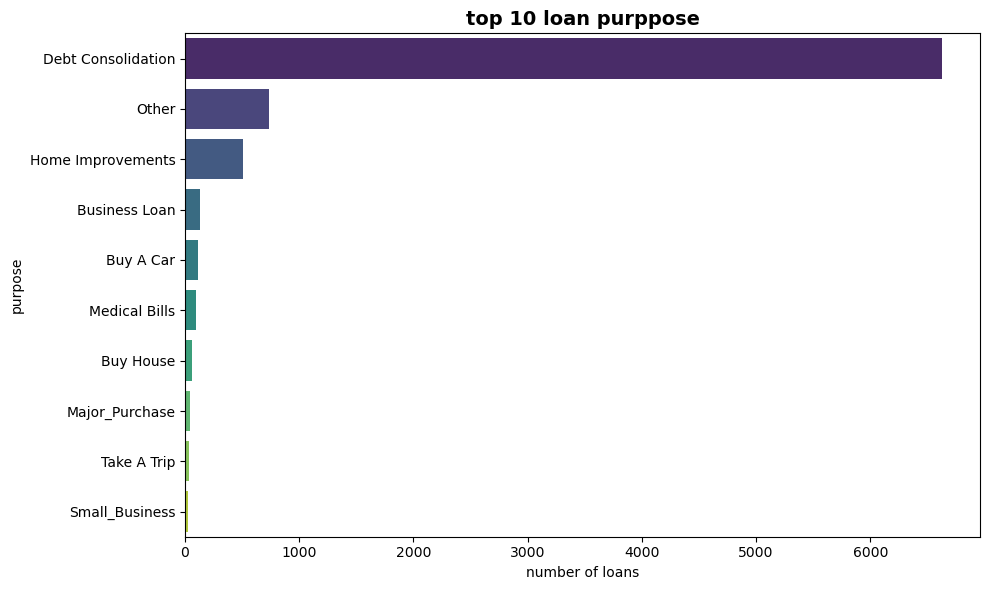

In [62]:
# Loan Distribution by Purpose (Horizontal Bar Chart)
purpose_counts=df['Purpose'].value_counts().head(10)
plt.figure(figsize=(10,6))
sns.barplot(x=purpose_counts.values, y=purpose_counts.index, palette='viridis')
plt.title('top 10 loan purppose',fontsize=14, fontweight='bold')
plt.xlabel('number of loans')
plt.ylabel('purpose')
plt.tight_layout()
plt.show()


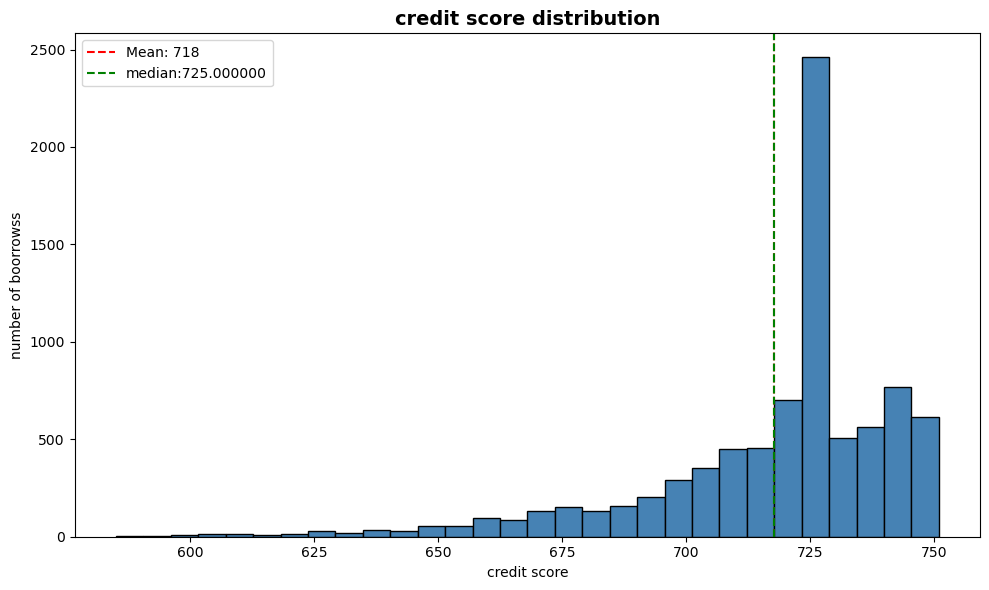

In [63]:
#Chart 2 — Credit Score Distribution (Histogram)
plt.figure(figsize=(10,6))
plt.hist(df['Credit Score'],bins=30, color='steelblue', edgecolor='black')
plt.title('credit score distribution', fontsize=14, fontweight='bold')
plt.xlabel('credit score')
plt.ylabel('number of boorrowss')
plt.axvline(df['Credit Score'].mean(), color='red', linestyle='--', label=f'Mean: {df["Credit Score"].mean():.0f}')
plt.axvline(df['Credit Score'].mean(), color='green', linestyle='--', label=f'median:{df["Credit Score"].median():0f}')
plt.legend()
plt.tight_layout()
plt.show()

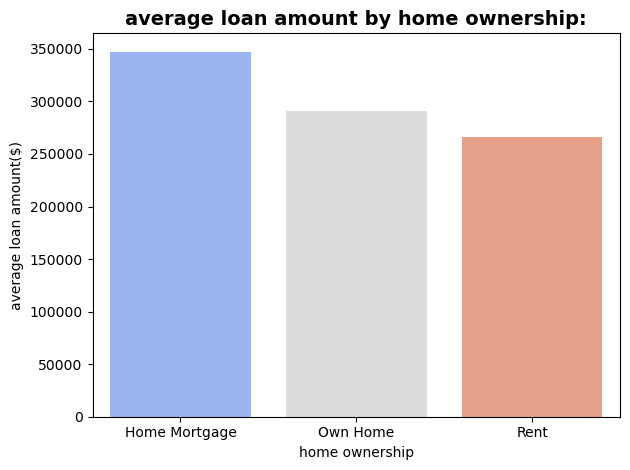

In [64]:
#Chart 3 — Average Loan Amount by Home Ownership
home_loan=df.groupby('Home Ownership')['Current Loan Amount'].mean().sort_values(ascending=False)
sns.barplot(x=home_loan.index, y=home_loan.values, palette='coolwarm')
plt.xlabel('home ownership')
plt.ylabel('average loan amount($)')
plt.title('average loan amount by home ownership:', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


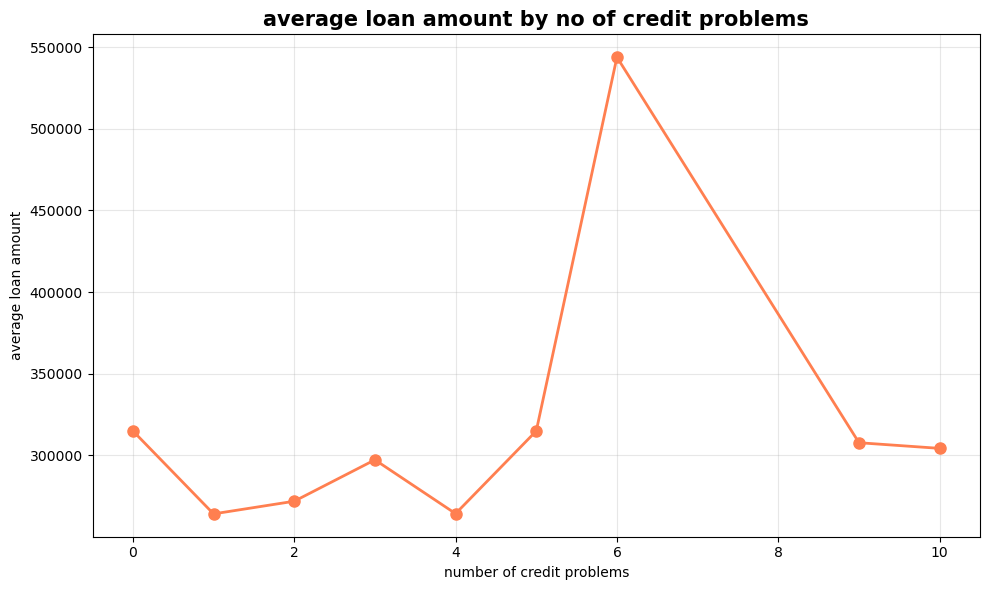

In [65]:
#Chart 4 — Credit Problems vs Average Loan Amount
credit_prob_loan= df.groupby('Number of Credit Problems')['Current Loan Amount'].mean().sort_index()
plt.figure(figsize=(10,6))
plt.plot(credit_prob_loan.index, credit_prob_loan.values, marker='o', color='coral', linewidth=2, markersize=8)
plt.title('average loan amount by no of credit problems', fontsize=15, fontweight='bold')
plt.xlabel('number of credit problems')
plt.ylabel('average loan amount')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

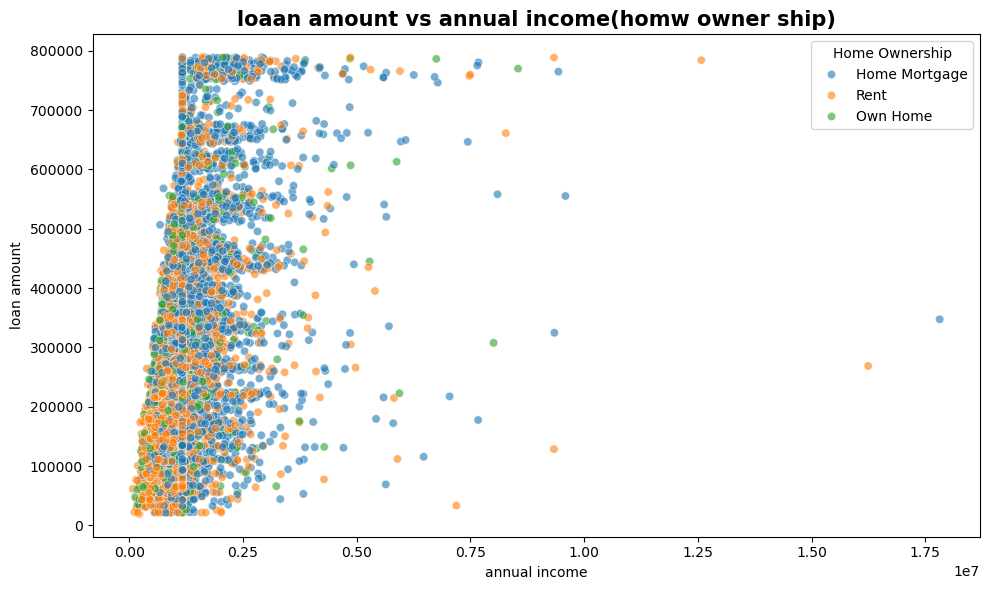

In [66]:
#Chart 5 — Loan Amount vs Annual Income Scatter Plot
plt.figure(figsize=(10,6))
sns.scatterplot(x='Annual Income', y='Current Loan Amount', data=df, hue='Home Ownership', alpha=0.6)
plt.title('loaan amount vs annual income(homw owner ship)', fontsize=15, fontweight='bold')
plt.xlabel('annual income')
plt.ylabel('loan amount')
plt.tight_layout()
plt.show()

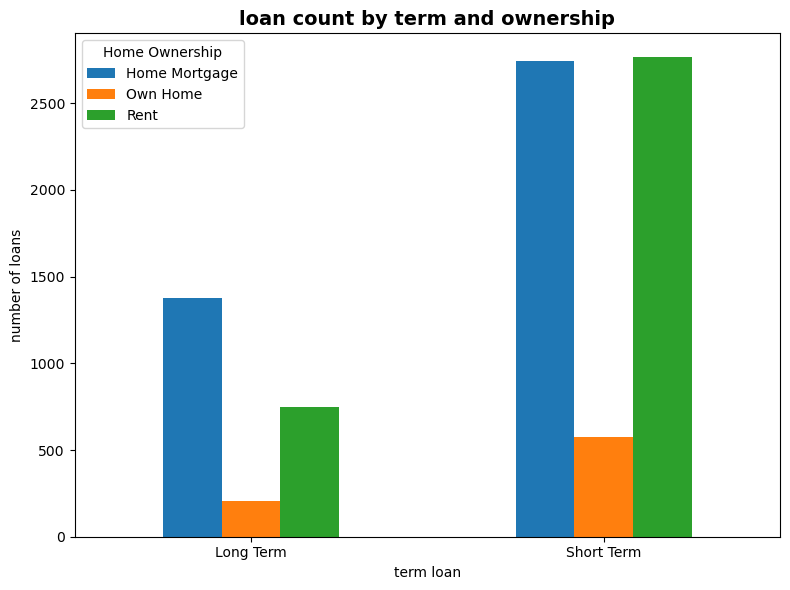

In [67]:
#Chart 6 — Loan Count by Term and Home Ownership (Grouped Bar Chart)
term_home = df.groupby(['Term', 'Home Ownership']).size().unstack()
plt.figure(figsize=(8,6))
term_home.plot(kind='bar', ax=plt.gca(), color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.title('loan count by term and ownership', fontsize=14, fontweight='bold')
plt.xlabel('term loan')
plt.ylabel('number of loans')
plt.legend(title='Home Ownership')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()